# Sound Based Lung Disease Detection -- ResNet50 Training

Transfer learning from ResNet50 (ImageNet pretrained) for 5-class respiratory disease
classification on ICBHI 2017.  
Input: `(N, 3, 128, 157)` log-mel + delta + delta-delta spectrograms from the preprocessing pipeline.


Model Training Pipeline:

1. ResNet50 (ImageNet-pretrained) with custom 2048->512->5 head.
2. Phase 1: head warmup (15 epochs, backbone frozen).
3. Phase 2: full fine-tune with differential LR (backbone 3e-5, head 3e-4) + SWA.
4. Regularisation: SpecAugment, Mixup (α=0.3), Focal Loss (γ=1.5), label smoothing, WeightedRandomSampler, weight decay, gradient clipping.



**Evaluation:**
- Six inference strategies: {best-ICBHI, best-F1, SWA} × {standard, MC-Dropout TTA}
- Metrics: ICBHI Score, Macro F1, Balanced Accuracy
- Both cycle-level and patient-level evaluation

**Cycle-level:** This will evaluate each breathing cycle independently to measure raw model capability, while **Patient-level** averages all cycle predictions per patient before diagnosing.
**Patient-wise splitting**: It will ensure no patient appears in both train and test, preventing the model from memorising individuals instead of learning disease patterns.

**Severe class imbalance (COPD = 72% of training data)**

Handled by three complementary mechanisms at different levels:
- **Data level:** Audio-domain oversampling brings minority classes to ≥300 cycles with genuinely different spectrograms (not copies).
- **Batch level:** WeightedRandomSampler with √-scaled inverse frequency ensures all 5 classes appear in every batch without catastrophically under-representing COPD
- **Gradient level:** Focal Loss (γ=1.5) with √ class weights down-weights easy/well-classified COPD samples and concentrates gradients on hard minority examples.


**Comparison with published ICBHI results**

Most ICBHI papers reporting 70-90% accuracy solve the 4-class adventitious sound task (normal/crackle/wheeze/both). This model achieves a cycle-level ICBHI Score of 69.5-70.3% and patient-level ICBHI Score of 68-73% across multiple runs (variance due to 19 test patients and GPU non-determinism). These results on 5 disease classes from audio alone are comparable to Le Nguyen (2024), who achieved 71.67% balanced accuracy on 4 classes using audio + metadata.


In [4]:
# Mount Google Drive if running in Colab (skip if running locally)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

---
## 0 — Imports and device

In [5]:
import os, json, time, random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn
from torchvision import models

from sklearn.metrics import f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU:  NVIDIA RTX 6000 Ada Generation
VRAM: 50.9 GB


---
## 1 — Config

In [6]:
# # Paths
# DATA_DIR  = '/content/drive/MyDrive/ICBHI_preprocessed'
# SAVE_DIR  = '/content/drive/MyDrive/RESNET50_reslut'
# os.makedirs(SAVE_DIR, exist_ok=True)

# Paths
DATA_DIR  = '/home/c24105216/applied_ML/ICBHI_preprocessed/ICBHI_preprocessed'
SAVE_DIR  = '/home/c24105216//applied_ML/resnet'
os.makedirs(SAVE_DIR, exist_ok=True)

# Training
BATCH_SIZE    = 64
PHASE1_EPOCHS = 15      # head warmup — 15 epochs give stable initialisation than 10
PHASE2_EPOCHS = 60
SWA_START     = 10      # start SWA early so it averages weights before heavy overfitting starts
PATIENCE        = 12      # stop sooner once val ICBHI stops improving

# Learning rates
PHASE1_LR    = 2e-3
BACKBONE_LR  = 3e-5     # 10x slower than head to avoid catastrophic forgetting
HEAD_LR    = 3e-4
SWA_LR       = 1e-5
WEIGHT_DECAY = 5e-4

# Loss
FOCAL_GAMMA   = 1.5   # higher than default — pushes more gradient toward hard minority samples
LABEL_SMOOTH = 0.05
USE_CLASS_WEIGHTS_IN_LOSS = True

# Regularisation
MIXUP_ALPHA = 0.3
GRAD_CLIP   = 1.0

# Inference
TTA_PASSES  = 5
NUM_WORKERS = 2
SEED        = 42


def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    s = torch.initial_seed() % (2 ** 32)
    np.random.seed(s); random.seed(s)


seed_everything(SEED)
g = torch.Generator(); g.manual_seed(SEED)
print(f'Seed: {SEED}')

Seed: 42


---
## 2 — Load metadata and preprocessed splits

In [7]:
with open(os.path.join(DATA_DIR, 'metadata.json')) as f:
    meta = json.load(f)

NUM_CLASSES  = meta['num_classes']
IDX_TO_LABEL = {int(k): v for k, v in meta['idx_to_label'].items()}
CLASS_NAMES  = [IDX_TO_LABEL[i] for i in range(NUM_CLASSES)]

# Sqrt-scaled class weights keep the COPD:Resp.Infection ratio at ~3.5x
# instead of ~36x (raw inverse freq), minority classes get more gradient
# without completely suppressing the majority class signal.

raw_w       = [meta['class_weights'][str(i)] for i in range(NUM_CLASSES)]
sqrt_w      = [w ** 0.5 for w in raw_w]
norm_factor = NUM_CLASSES / sum(sqrt_w)
norm_sqrt_w = [w * norm_factor for w in sqrt_w]

train_npz = np.load(os.path.join(DATA_DIR, 'train_data.npz'))
val_npz   = np.load(os.path.join(DATA_DIR, 'val_data.npz'))
test_npz  = np.load(os.path.join(DATA_DIR, 'test_data.npz'))

train_labels_all = train_npz['disease_labels']
val_labels_all   = val_npz['disease_labels']
test_labels_all  = test_npz['disease_labels']

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train: {len(train_labels_all):,}  Val: {len(val_labels_all):,}  Test: {len(test_labels_all):,}')
print(f'\nClass distribution (train):')
for i, name in enumerate(CLASS_NAMES):
    n   = (train_labels_all == i).sum()
    pct = 100 * n / len(train_labels_all)
    print(f'  {name:<20s}: {n:>5d}  ({pct:.1f}%)')
print(f'\nSqrt class weights (normalised): {[f"{w:.3f}" for w in norm_sqrt_w]}')
print(f'Input shape: {meta["spectrogram_shape"]}')

Classes (5): ['COPD', 'Healthy', 'Other Chronic', 'Pneumonia', 'Resp. Infection']
Train: 5,960  Val: 964  Test: 859

Class distribution (train):
  COPD                :  4309  (72.3%)
  Healthy             :   478  (8.0%)
  Other Chronic       :   402  (6.7%)
  Pneumonia           :   414  (6.9%)
  Resp. Infection     :   357  (6.0%)

Sqrt class weights (normalised): ['0.358', '1.074', '1.171', '1.154', '1.243']
Input shape: [3, 128, 157]


---
## 3 — Focal Loss

Focal Loss: down-weights easy samples so gradients focus on hard minority examples.
gamma=1.5 controls focusing strength, label_smoothing=0.05 prevents overconfident predictions.


In [8]:
class FocalLoss(nn.Module):

    def __init__(self, weight=None, gamma=1.0, label_smoothing=0.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma
        self.ls     = label_smoothing

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.weight,
                             label_smoothing=self.ls, reduction='none')
        with torch.no_grad():
            pt = (F.softmax(inputs, dim=1)
                  .gather(1, targets.unsqueeze(1))
                  .squeeze(1).clamp(min=1e-8))
        return (((1 - pt) ** self.gamma) * ce).mean()


loss_weights = (
    torch.FloatTensor(norm_sqrt_w).to(device)
    if USE_CLASS_WEIGHTS_IN_LOSS else None
)
criterion = FocalLoss(weight=loss_weights, gamma=FOCAL_GAMMA,
                      label_smoothing=LABEL_SMOOTH)
print(f'FocalLoss: gamma={FOCAL_GAMMA}, label_smoothing={LABEL_SMOOTH}')
print(f'Class weights: {loss_weights}')

FocalLoss: gamma=1.5, label_smoothing=0.05
Class weights: tensor([0.3577, 1.0741, 1.1712, 1.1541, 1.2428], device='cuda:0')


---
## 4 — Dataset & DataLoaders

In [9]:
def spec_augment(spec, n_freq=2, freq_w=15, n_time=2, time_w=25):
    aug = spec.copy()
    _, n_mels, n_frames = aug.shape
    for _ in range(n_freq):
        f  = np.random.randint(1, min(freq_w, n_mels))
        f0 = np.random.randint(0, n_mels - f)
        aug[:, f0:f0 + f, :] = 0.0
    for _ in range(n_time):
        t  = np.random.randint(1, min(time_w, n_frames))
        t0 = np.random.randint(0, n_frames - t)
        aug[:, :, t0:t0 + t] = 0.0
    return aug


class ICBHIDataset(Dataset):
    def __init__(self, npz_path, augment=False):
        data             = np.load(npz_path)
        self.specs       = data['spectrograms']
        self.labels      = data['disease_labels']
        self.patient_ids = (data['patient_ids'] if 'patient_ids' in data.files
                            else np.arange(len(self.labels)))
        self.augment     = augment

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        spec = self.specs[idx].copy()
        if self.augment:
            spec = spec_augment(spec)
        return torch.FloatTensor(spec), torch.tensor(self.labels[idx], dtype=torch.long)


train_ds     = ICBHIDataset(os.path.join(DATA_DIR, 'train_data.npz'), augment=True)
train_ds_raw = ICBHIDataset(os.path.join(DATA_DIR, 'train_data.npz'), augment=False)
val_ds       = ICBHIDataset(os.path.join(DATA_DIR, 'val_data.npz'),   augment=False)
test_ds      = ICBHIDataset(os.path.join(DATA_DIR, 'test_data.npz'),  augment=False)

# WeightedRandomSampler: prob of drawing a sample ∝ sqrt(inverse class freq)
sample_weights = [norm_sqrt_w[int(l)] for l in train_ds.labels]
sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights),
                                len(sample_weights), replacement=True, generator=g)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
                          worker_init_fn=seed_worker, generator=g)
train_loader_raw = DataLoader(train_ds_raw, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              worker_init_fn=seed_worker)
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True,
                         worker_init_fn=seed_worker)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True,
                         worker_init_fn=seed_worker)

print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')
print(f'Train batches: {len(train_loader)} (drop_last=True)')
x, y = next(iter(train_loader))
print(f'Batch: x={x.shape}, y={y.shape}')
print(f'Test patients: {len(np.unique(test_ds.patient_ids))} unique')

Train: 5,960  Val: 964  Test: 859
Train batches: 93 (drop_last=True)
Batch: x=torch.Size([64, 3, 128, 157]), y=torch.Size([64])
Test patients: 19 unique


---
## 5 — Model: ResNet50 with custom head

1. ResNet50 (IMAGENET1K_V2) with the default FC swapped for a two-layer MLP head.The 3-channel spectrogram matches ResNet50's RGB input convention directly.


2. ResNet50 backbone with custom head: 2048->512->5.
Dropout decreases (0.4->0.3) toward output — higher uncertainty at entry where
ImageNet features meet lung-sound classification for the first time.



In [10]:
def build_resnet50(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(m.fc.in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return m


model = build_resnet50(NUM_CLASSES).to(device)
total  = sum(p.numel() for p in model.parameters())
head_n = sum(p.numel() for p in model.fc.parameters())
print(f'Total params: {total:,}  |  Head params (Phase 1 only): {head_n:,}')

Total params: 24,559,685  |  Head params (Phase 1 only): 1,051,653


---
## 6 — Metrics

In [11]:
def compute_icbhi_score(y_true, y_pred, num_classes):
    """ICBHI Score = (macro-Sensitivity + macro-Specificity) / 2.
    Official challenge metric from Rocha et al. 2019.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    se_list, sp_list = [], []
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        tn = np.sum((y_true != c) & (y_pred != c))
        fp = np.sum((y_true != c) & (y_pred == c))
        se_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        sp_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return 100.0 * (np.mean(se_list) + np.mean(sp_list)) / 2.0


def compute_metrics(y_true, y_pred):
    icbhi    = compute_icbhi_score(y_true, y_pred, NUM_CLASSES)
    macro_f1 = 100.0 * f1_score(y_true, y_pred, average='macro', zero_division=0)
    bal_acc  = 100.0 * balanced_accuracy_score(y_true, y_pred)
    return icbhi, macro_f1, bal_acc

---
## 7 — Training helpers

Mixup: blend two samples with Beta(0.3,0.3)-sampled weight → smoother decision boundaries

MC-Dropout TTA: keep BatchNorm frozen (stable stats), re-enable only Dropout for stochastic passes

In [12]:
scaler = torch.amp.GradScaler('cuda')


def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def train_epoch(model, loader, optimizer, use_mixup=True):
    model.train()
    total_loss, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.amp.autocast('cuda'):
            if use_mixup:
                xm, ya, yb, lam = mixup_data(x, y, MIXUP_ALPHA)
                pred = model(xm)
                loss = lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)
            else:
                pred = model(x)
                loss = criterion(pred, y)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * x.size(0); n += x.size(0)
    return total_loss / n


@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    total_loss, preds, labels, probs = 0.0, [], [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.amp.autocast('cuda'):
            logits = model(x)
            total_loss += criterion(logits, y).item() * x.size(0)
        p = F.softmax(logits.float(), dim=1)
        preds.extend(p.argmax(1).cpu().numpy())
        labels.extend(y.cpu().numpy())
        probs.append(p.cpu())
    return total_loss / len(loader.dataset), np.array(preds), np.array(labels), torch.cat(probs)


def enable_mc_dropout(model):
    """Keep Batch Normalisation in eval mode
    re-enable only Dropout for stochastic forward passes."""
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            m.train()


@torch.no_grad()
def tta_inference(model, dataset, n_passes=5):
    """MC-Dropout TTA: average softmax over n_passes stochastic forward passes."""
    probs_sum = torch.zeros(len(dataset), NUM_CLASSES)
    enable_mc_dropout(model)
    for _ in range(n_passes):
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS)
        start = 0
        for x, _ in loader:
            with torch.amp.autocast('cuda'):
                logits = model(x.to(device)).cpu()
            probs_sum[start:start + x.size(0)] += torch.softmax(logits.float(), dim=1)
            start += x.size(0)
    model.eval()
    return probs_sum / n_passes

---
## 8 — Phase 1: Head warmup (backbone frozen)

Backbone is frozen..
Only the new head trains for `PHASE1_EPOCHS` epochs.  
This stops large random gradients from corrupting the pretrained ImageNet weights before the head has stabilised.

In [13]:
for p in model.parameters():    p.requires_grad = False
for p in model.fc.parameters(): p.requires_grad = True

optimizer_p1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                          lr=PHASE1_LR, weight_decay=WEIGHT_DECAY)
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=1e-5)

hist = {'phase': [], 'epoch': [], 'train_loss': [], 'val_loss': [],
        'val_icbhi': [], 'val_f1': [], 'val_bal_acc': [], 'lr': []}

print(f'{"Ep":>3s} {"TrLoss":>8s} {"VaLoss":>8s} {"ICBHI":>7s} {"MacroF1":>8s} {"BalAcc":>8s}')
print('-' * 52)

t0 = time.time()
for ep in range(1, PHASE1_EPOCHS + 1):
    tr_loss                        = train_epoch(model, train_loader, optimizer_p1)
    va_loss, va_preds, va_labels, _ = eval_model(model, val_loader)
    icbhi, mf1, bal                = compute_metrics(va_labels, va_preds)
    scheduler_p1.step()

    hist['phase'].append('head');   hist['epoch'].append(ep)
    hist['train_loss'].append(tr_loss); hist['val_loss'].append(va_loss)
    hist['val_icbhi'].append(icbhi);    hist['val_f1'].append(mf1)
    hist['val_bal_acc'].append(bal);    hist['lr'].append(optimizer_p1.param_groups[0]['lr'])

    print(f'{ep:3d} {tr_loss:8.4f} {va_loss:8.4f} {icbhi:6.1f}% {mf1:7.1f}% {bal:7.1f}%')

print(f'\nPhase 1 done in {(time.time()-t0)/60:.1f} min')

 Ep   TrLoss   VaLoss   ICBHI  MacroF1   BalAcc
----------------------------------------------------
  1   0.8997   0.5496   60.9%    28.2%    33.6%
  2   0.8707   0.5620   60.2%    26.6%    34.1%
  3   0.8565   0.5968   55.9%    18.3%    27.9%
  4   0.8368   0.5910   56.7%    20.1%    28.2%
  5   0.8436   0.5996   58.6%    19.6%    33.0%
  6   0.8315   0.5395   60.5%    27.2%    33.7%
  7   0.8346   0.5749   58.0%    22.2%    30.3%
  8   0.8377   0.5562   58.8%    25.5%    31.3%
  9   0.8269   0.5771   58.6%    21.9%    31.8%
 10   0.8120   0.5454   61.0%    27.0%    34.7%
 11   0.8006   0.5534   59.5%    26.5%    31.9%
 12   0.8172   0.5714   58.7%    22.9%    31.4%
 13   0.7963   0.5400   60.7%    26.5%    33.9%
 14   0.7974   0.5524   60.3%    25.9%    33.8%
 15   0.8088   0.5629   59.9%    25.3%    33.5%

Phase 1 done in 0.2 min


---
## 9 — Phase 2: Full fine-tune + SWA

All parameters unfrozen. Differential LRs: backbone 10× slower than head (prevents catastrophic forgetting).  
SWA(Stochastic Weight Averaging) starts at epoch `SWA_START` — averaging weights before overfitting sets in finds a flatter, more generalisable minimum.  
Early stopping on val ICBHI Score with patience `PATIENCE`.

In [14]:
for p in model.parameters(): p.requires_grad = True

backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n]
head_params_p2  = list(model.fc.parameters())

optimizer_p2 = optim.AdamW(
    [{'params': backbone_params, 'lr': BACKBONE_LR},
     {'params': head_params_p2,  'lr': HEAD_LR}],
    weight_decay=WEIGHT_DECAY)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_p2, T_0=10, T_mult=1, eta_min=1e-6)

swa_model  = AveragedModel(model)
swa_sched  = SWALR(optimizer_p2, swa_lr=SWA_LR)
swa_active = False

path_best_icbhi = os.path.join(SAVE_DIR, 'best_resnet50_icbhi.pth')
path_best_f1    = os.path.join(SAVE_DIR, 'best_resnet50_f1.pth')

best_val_icbhi = 0.0
best_val_f1    = 0.0
best_epoch     = 0
patience_cnt   = 0

print(f'Backbone LR: {BACKBONE_LR:.0e}  |  Head LR: {HEAD_LR:.0e}')
print(f'SWA activates after Phase 2 epoch {SWA_START}')
print(f'Early stopping patience = {PATIENCE}')
print(f'{"Ep":>3s} {"TrLoss":>8s} {"VaLoss":>8s} {"ICBHI":>7s} {"MacroF1":>8s} {"BalAcc":>8s}')
print('-' * 52)

t1 = time.time()
for ep in range(1, PHASE2_EPOCHS + 1):
    tr_loss                         = train_epoch(model, train_loader, optimizer_p2)
    va_loss, va_preds, va_labels, _ = eval_model(model, val_loader)
    icbhi, mf1, bal                 = compute_metrics(va_labels, va_preds)

    if ep >= SWA_START:
        if not swa_active:
            swa_active = True
            print(f'  -> SWA activated at Phase 2 epoch {ep}')
        swa_model.update_parameters(model)
        swa_sched.step()
        lr = SWA_LR
    else:
        scheduler_p2.step()
        lr = optimizer_p2.param_groups[1]['lr']

    total_ep = PHASE1_EPOCHS + ep
    hist['phase'].append('full');      hist['epoch'].append(total_ep)
    hist['train_loss'].append(tr_loss); hist['val_loss'].append(va_loss)
    hist['val_icbhi'].append(icbhi);    hist['val_f1'].append(mf1)
    hist['val_bal_acc'].append(bal);    hist['lr'].append(lr)

    marker = ''
    # *I = new best validation ICBHI Score was reached at this epoch.
    # *F = new best validation Macro F1 was reached at this epoch.
    if icbhi > best_val_icbhi:
        best_val_icbhi = icbhi; best_epoch = total_ep; patience_cnt = 0
        torch.save(model.state_dict(), path_best_icbhi); marker += ' *I'
    else:
        patience_cnt += 1
    if mf1 > best_val_f1:
        best_val_f1 = mf1
        torch.save(model.state_dict(), path_best_f1); marker += ' *F'

    print(f'{ep:3d} {tr_loss:8.4f} {va_loss:8.4f} {icbhi:6.1f}% {mf1:7.1f}% {bal:7.1f}%{marker}')

    if patience_cnt >= PATIENCE:
        print(f'  -> Early stop at Phase 2 epoch {ep} (patience={PATIENCE})')
        break

# Recompute BN stats on unaugmented data so SWA model normalises correctly at inference
if swa_active:
    print('\nUpdating SWA batch-norm statistics on unaugmented data...')
    update_bn(train_loader_raw, swa_model, device=device)
    torch.save(swa_model.module.state_dict(), os.path.join(SAVE_DIR, 'swa_resnet50.pth'))
    print('SWA model saved.')

print(f'\nPhase 2 done in {(time.time()-t1)/60:.1f} min')
print(f'Best val ICBHI: {best_val_icbhi:.1f}% at epoch {best_epoch}')
print(f'Best val Macro F1: {best_val_f1:.1f}%')

Backbone LR: 3e-05  |  Head LR: 3e-04
SWA activates after Phase 2 epoch 10
Early stopping patience = 12
 Ep   TrLoss   VaLoss   ICBHI  MacroF1   BalAcc
----------------------------------------------------
  1   0.7545   0.3703   63.3%    30.8%    35.7% *I *F
  2   0.6487   0.3151   68.4%    37.5%    43.1% *I *F
  3   0.5730   0.3096   68.9%    39.1%    43.8% *I *F
  4   0.5341   0.2917   68.1%    38.8%    41.8%
  5   0.5091   0.3137   67.5%    37.2%    40.6%
  6   0.5165   0.3092   67.7%    37.9%    41.0%
  7   0.4913   0.3189   68.3%    38.9%    42.0%
  8   0.4960   0.3294   68.1%    38.3%    41.6%
  9   0.4234   0.3237   68.5%    39.5%    42.4% *F
  -> SWA activated at Phase 2 epoch 10
 10   0.4747   0.3250   67.5%    37.7%    40.5%
 11   0.4400   0.3231   67.3%    37.4%    40.1%
 12   0.4589   0.3280   67.9%    38.1%    41.2%
 13   0.4625   0.3190   67.7%    38.2%    40.9%
 14   0.4485   0.3318   67.1%    37.1%    39.6%
 15   0.4315   0.3218   66.8%    36.7%    39.1%
  -> Early stop

---
## 10 — Training curves

Loss curve shows the model learning in two stages... slow progress with frozen backbone, then sharp improvement once all layers unfreeze. ICBHI Score follows the same pattern, confirming that adapting the pretrained features is what drives performance. Macro F1 and Balanced Accuracy are noisier because they are stricter metrics that expose the model's difficulty with rare classes.

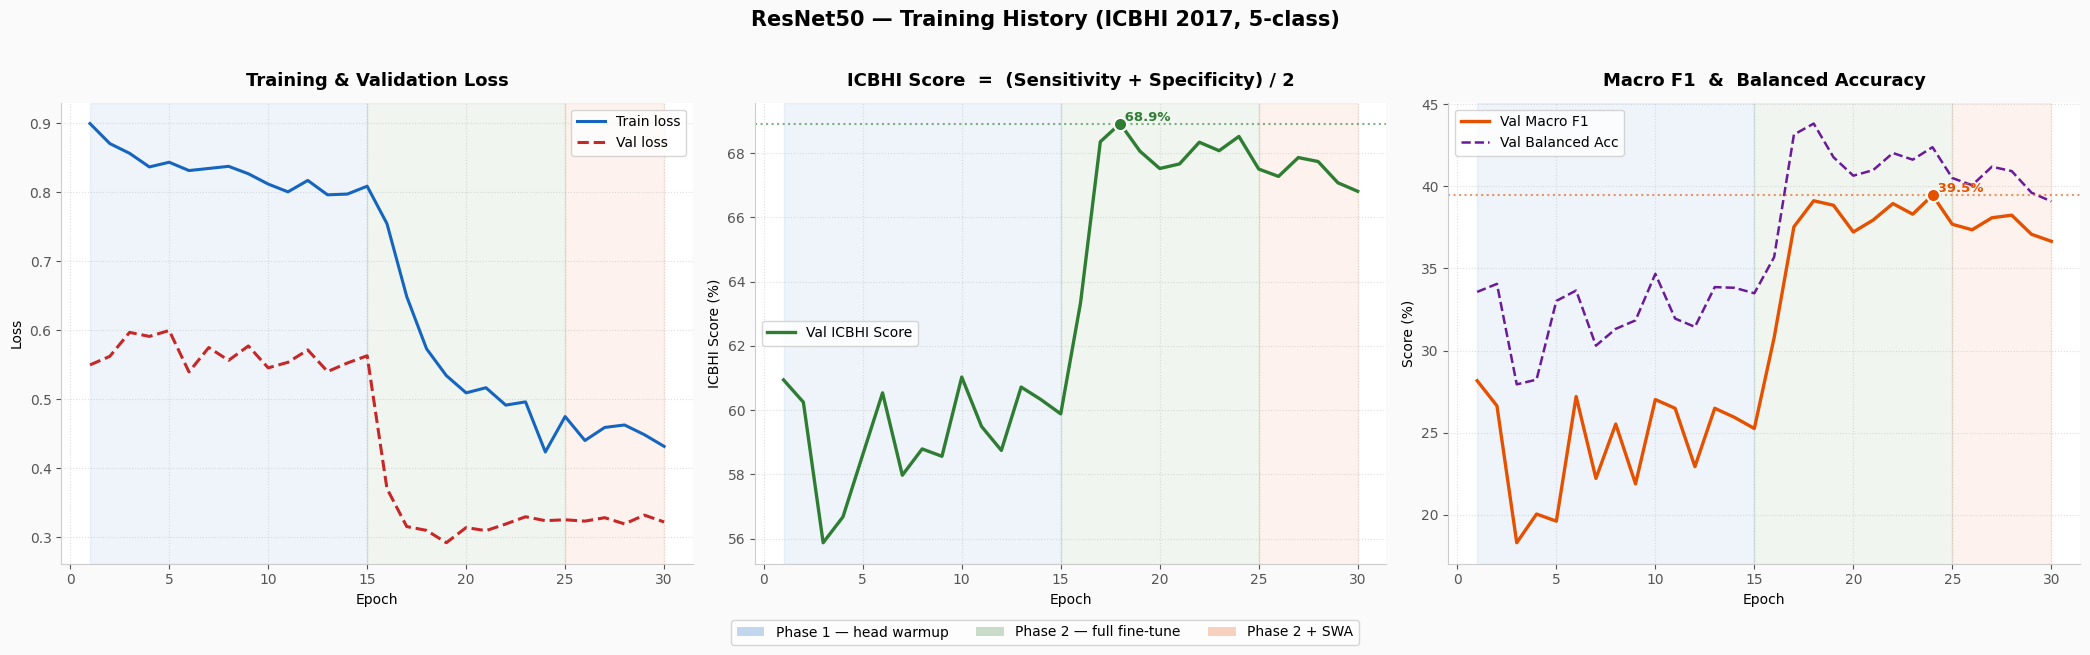

In [15]:
epochs     = hist['epoch']
p1_end     = PHASE1_EPOCHS
p2_swa     = PHASE1_EPOCHS + SWA_START
total_ep   = epochs[-1]

C = {'train': '#1565C0', 'val': '#C62828', 'icbhi': '#2E7D32',
     'f1': '#E65100', 'bal': '#6A1B9A'}

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor('#FAFAFA')
for ax in axes:
    ax.set_facecolor('#FFFFFF')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC'); ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(colors='#555555', labelsize=10)

def add_bands(ax):
    ax.axvspan(1,       p1_end,   alpha=0.07, color='#1565C0', zorder=0)
    ax.axvspan(p1_end,  p2_swa,   alpha=0.07, color='#2E7D32', zorder=0)
    if swa_active:
        ax.axvspan(p2_swa, total_ep, alpha=0.07, color='#E65100', zorder=0)

# Loss
add_bands(axes[0])
axes[0].plot(epochs, hist['train_loss'], color=C['train'], lw=2.2, label='Train loss')
axes[0].plot(epochs, hist['val_loss'],   color=C['val'],   lw=2.2, ls='--', label='Val loss')
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.4, ls=':')

# ICBHI Score
add_bands(axes[1])
axes[1].plot(epochs, hist['val_icbhi'], color=C['icbhi'], lw=2.4, label='Val ICBHI Score')
bv = max(hist['val_icbhi']); be = epochs[hist['val_icbhi'].index(bv)]
axes[1].axhline(bv, color=C['icbhi'], ls=':', lw=1.5, alpha=0.6)
axes[1].scatter([be], [bv], color=C['icbhi'], s=90, zorder=6, edgecolors='white', lw=1.5)
axes[1].annotate(f' {bv:.1f}%', xy=(be, bv), fontsize=9.5, color=C['icbhi'],
                 va='bottom', fontweight='bold')
axes[1].set_title('ICBHI Score  =  (Sensitivity + Specificity) / 2',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ICBHI Score (%)')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.4, ls=':')

# Macro F1 + Balanced Accuracy
add_bands(axes[2])
axes[2].plot(epochs, hist['val_f1'],      color=C['f1'],  lw=2.4, label='Val Macro F1')
axes[2].plot(epochs, hist['val_bal_acc'], color=C['bal'], lw=1.8, ls='--', label='Val Balanced Acc')
bf = max(hist['val_f1']); bfe = epochs[hist['val_f1'].index(bf)]
axes[2].axhline(bf, color=C['f1'], ls=':', lw=1.5, alpha=0.6)
axes[2].scatter([bfe], [bf], color=C['f1'], s=90, zorder=6, edgecolors='white', lw=1.5)
axes[2].annotate(f' {bf:.1f}%', xy=(bfe, bf), fontsize=9.5, color=C['f1'],
                 va='bottom', fontweight='bold')
axes[2].set_title('Macro F1  &  Balanced Accuracy', fontsize=13, fontweight='bold', pad=12)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score (%)')
axes[2].legend(fontsize=10); axes[2].grid(True, alpha=0.4, ls=':')

patches = [
    Patch(facecolor='#1565C0', alpha=0.25, label='Phase 1 — head warmup'),
    Patch(facecolor='#2E7D32', alpha=0.25, label='Phase 2 — full fine-tune'),
]
if swa_active:
    patches.append(Patch(facecolor='#E65100', alpha=0.25, label='Phase 2 + SWA'))
fig.legend(handles=patches, loc='lower center', ncol=len(patches),
           fontsize=10, bbox_to_anchor=(0.5, -0.05))

fig.suptitle('ResNet50 — Training History (ICBHI 2017, 5-class)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=180, bbox_inches='tight')
plt.show()

---
## 11 — Test inference: six strategies

Six candidates are evaluated: {best-ICBHI ckpt, best-F1 ckpt, SWA} × {standard, MC-Dropout TTA×5}.  
The best cycle-level method by ICBHI Score is selected as the final cycle-level result.

In [16]:
# Best ICBHI checkpoint — standard + TTA
model.load_state_dict(torch.load(path_best_icbhi, map_location=device))
model.eval()
print(f'Best ICBHI checkpoint (epoch {best_epoch})')

_, std_preds_icbhi, std_labels, std_probs_icbhi = eval_model(model, test_loader)
icbhi_std, f1_std, bal_std = compute_metrics(std_labels, std_preds_icbhi)
print(f'  Standard:  ICBHI={icbhi_std:.1f}%  MacroF1={f1_std:.1f}%  BalAcc={bal_std:.1f}%')

tta_probs_icbhi = tta_inference(model, test_ds, TTA_PASSES)
tta_preds_icbhi = tta_probs_icbhi.argmax(1).numpy()
icbhi_tta, f1_tta, bal_tta = compute_metrics(std_labels, tta_preds_icbhi)
print(f'  TTA x{TTA_PASSES}:    ICBHI={icbhi_tta:.1f}%  MacroF1={f1_tta:.1f}%  BalAcc={bal_tta:.1f}%')

# Best F1 checkpoint — standard + TTA
model.load_state_dict(torch.load(path_best_f1, map_location=device))
model.eval()
print(f'\nBest F1 checkpoint')

_, std_preds_f1, _, std_probs_f1 = eval_model(model, test_loader)
icbhi_f1c, f1_f1c, bal_f1c = compute_metrics(std_labels, std_preds_f1)
print(f'  Standard:  ICBHI={icbhi_f1c:.1f}%  MacroF1={f1_f1c:.1f}%  BalAcc={bal_f1c:.1f}%')

tta_probs_f1 = tta_inference(model, test_ds, TTA_PASSES)
tta_preds_f1 = tta_probs_f1.argmax(1).numpy()
icbhi_f1t, f1_f1t, bal_f1t = compute_metrics(std_labels, tta_preds_f1)
print(f'  TTA x{TTA_PASSES}:    ICBHI={icbhi_f1t:.1f}%  MacroF1={f1_f1t:.1f}%  BalAcc={bal_f1t:.1f}%')

# SWA model — standard + TTA
swa_icbhi = swa_f1 = swa_bal = 0.0
swa_tta_icbhi = swa_tta_f1 = swa_tta_bal = 0.0
swa_preds_arr = std_preds_icbhi; swa_probs_arr = std_probs_icbhi
swa_tta_preds = std_preds_icbhi; swa_tta_probs = std_probs_icbhi

if swa_active:
    swa_model.module.load_state_dict(
        torch.load(os.path.join(SAVE_DIR, 'swa_resnet50.pth'), map_location=device))
    _, swa_preds_arr, _, swa_probs_arr = eval_model(swa_model, test_loader)
    swa_icbhi, swa_f1, swa_bal = compute_metrics(std_labels, swa_preds_arr)
    print(f'\nSWA model')
    print(f'  Standard:  ICBHI={swa_icbhi:.1f}%  MacroF1={swa_f1:.1f}%  BalAcc={swa_bal:.1f}%')

    swa_tta_probs = tta_inference(swa_model, test_ds, TTA_PASSES)
    swa_tta_preds = swa_tta_probs.argmax(1).numpy()
    swa_tta_icbhi, swa_tta_f1, swa_tta_bal = compute_metrics(std_labels, swa_tta_preds)
    print(f'  TTA x{TTA_PASSES}:    ICBHI={swa_tta_icbhi:.1f}%  MacroF1={swa_tta_f1:.1f}%  BalAcc={swa_tta_bal:.1f}%')

# Collect all six candidates
candidates = {
    'ICBHI_Ckpt_Standard': (icbhi_std,  f1_std,  bal_std,  std_preds_icbhi, std_probs_icbhi),
    'ICBHI_Ckpt_TTA':      (icbhi_tta,  f1_tta,  bal_tta,  tta_preds_icbhi, tta_probs_icbhi),
    'F1_Ckpt_Standard':    (icbhi_f1c,  f1_f1c,  bal_f1c,  std_preds_f1,    std_probs_f1),
    'F1_Ckpt_TTA':         (icbhi_f1t,  f1_f1t,  bal_f1t,  tta_preds_f1,    tta_probs_f1),
}
if swa_active:
    candidates['SWA_Standard'] = (swa_icbhi,     swa_f1,     swa_bal,     swa_preds_arr, swa_probs_arr)
    candidates['SWA_TTA']      = (swa_tta_icbhi, swa_tta_f1, swa_tta_bal, swa_tta_preds, swa_tta_probs)

best_cycle_method = max(candidates, key=lambda k: candidates[k][0])
bci, bcf, bcb, bc_preds, bc_probs = candidates[best_cycle_method]
print(f'\nBest cycle-level: {best_cycle_method}  ->  ICBHI={bci:.1f}%  MacroF1={bcf:.1f}%')

Best ICBHI checkpoint (epoch 18)


  Standard:  ICBHI=69.2%  MacroF1=36.1%  BalAcc=50.5%
  TTA x5:    ICBHI=68.2%  MacroF1=35.2%  BalAcc=48.6%

Best F1 checkpoint
  Standard:  ICBHI=67.9%  MacroF1=37.3%  BalAcc=47.8%
  TTA x5:    ICBHI=67.1%  MacroF1=36.3%  BalAcc=46.2%

SWA model
  Standard:  ICBHI=68.7%  MacroF1=38.7%  BalAcc=49.4%
  TTA x5:    ICBHI=68.7%  MacroF1=38.5%  BalAcc=49.6%

Best cycle-level: ICBHI_Ckpt_Standard  ->  ICBHI=69.2%  MacroF1=36.1%


---
## 12 — Patient-level aggregation

Average softmax probability vectors across all cycles from the same patient, then argmax.  
This mirrors clinical practice (a clinician listens to many cycles before diagnosing) and smooths cycle-level noise.

In [17]:
patient_ids = test_ds.patient_ids
unique_pids = np.unique(patient_ids)
print(f'Unique test patients: {len(unique_pids)}')


def patient_aggregate(probs_tensor, patient_ids, unique_pids, std_labels):
    probs = probs_tensor.numpy() if isinstance(probs_tensor, torch.Tensor) else probs_tensor
    pat_preds, pat_true = [], []
    for pid in unique_pids:
        mask = patient_ids == pid
        avg  = probs[mask].mean(axis=0)
        pat_preds.append(avg.argmax())
        labels_pid = std_labels[mask]
        assert len(np.unique(labels_pid)) == 1, f'Patient {pid} has mixed labels'
        pat_true.append(int(labels_pid[0]))
    return np.array(pat_preds), np.array(pat_true)


patient_results = {}
for name, (ci, cf, cb, cpreds, cprobs) in candidates.items():
    p_preds, p_true = patient_aggregate(cprobs, patient_ids, unique_pids, std_labels)
    p_icbhi, p_f1, p_bal = compute_metrics(p_true, p_preds)
    patient_results[name] = (p_icbhi, p_f1, p_bal, p_preds, p_true)
    print(f'{name:<22s} -> patient ICBHI={p_icbhi:.1f}%  F1={p_f1:.1f}%')

best_patient_method = max(patient_results, key=lambda k: patient_results[k][0])
pi, pf, pb, final_pat_preds, final_pat_true = patient_results[best_patient_method]
print(f'\nBest patient-level: {best_patient_method}  ->  ICBHI={pi:.1f}%  MacroF1={pf:.1f}%')

Unique test patients: 19
ICBHI_Ckpt_Standard    -> patient ICBHI=73.1%  F1=49.5%
ICBHI_Ckpt_TTA         -> patient ICBHI=73.1%  F1=49.5%
F1_Ckpt_Standard       -> patient ICBHI=77.1%  F1=55.8%
F1_Ckpt_TTA            -> patient ICBHI=78.7%  F1=59.5%
SWA_Standard           -> patient ICBHI=79.2%  F1=58.3%
SWA_TTA                -> patient ICBHI=79.2%  F1=58.3%

Best patient-level: SWA_Standard  ->  ICBHI=79.2%  MacroF1=58.3%


---
## 13 — Confusion matrices

The confusion matrix shows the model classifies the dominant class (COPD) but sometimes mistakes rarer diseases for COPD, because it has seen far more COPD examples during training. When we combine all predictions per patient instead of looking at individual breaths, the results get noticeably better.

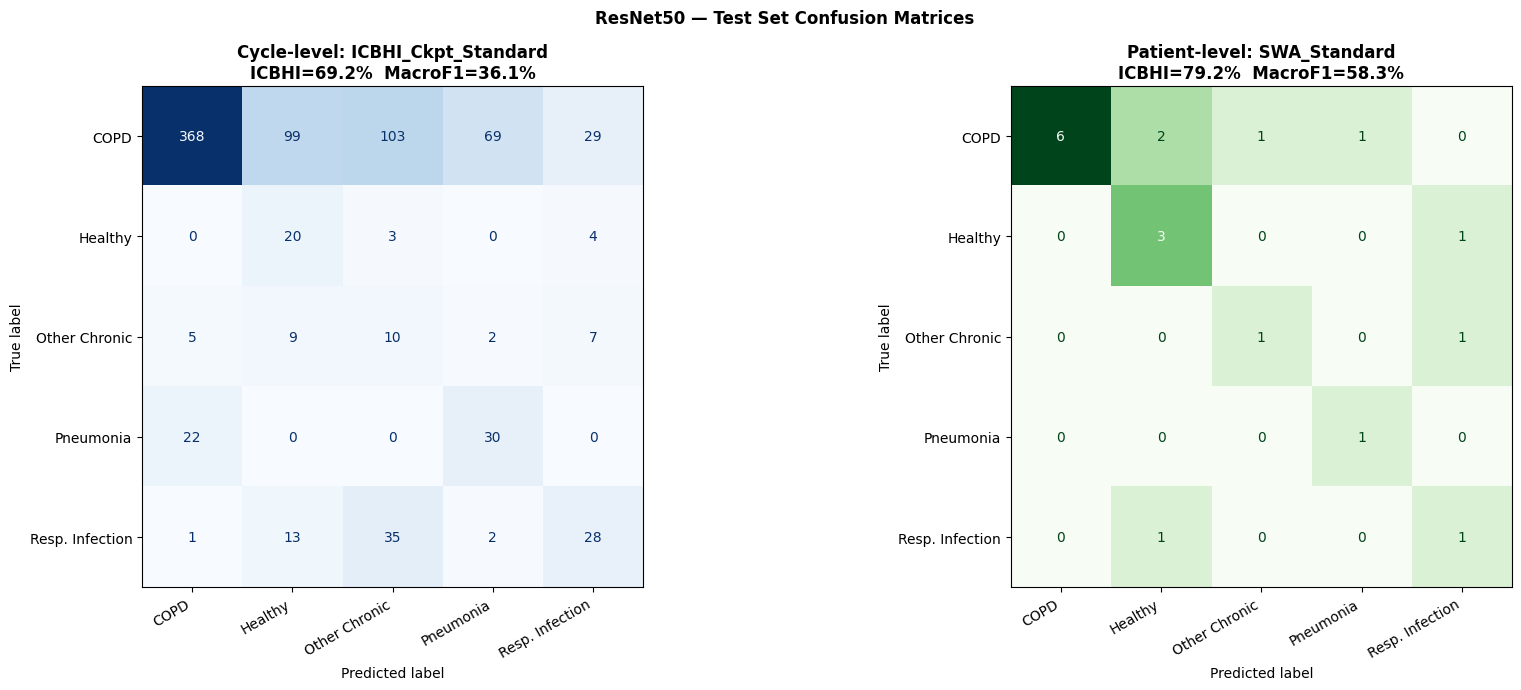

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cm_c = confusion_matrix(std_labels, bc_preds)
ConfusionMatrixDisplay(cm_c, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title(f'Cycle-level: {best_cycle_method}\nICBHI={bci:.1f}%  MacroF1={bcf:.1f}%',
                  fontweight='bold')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

cm_p = confusion_matrix(final_pat_true, final_pat_preds)
ConfusionMatrixDisplay(cm_p, display_labels=CLASS_NAMES).plot(
    ax=axes[1], cmap='Greens', values_format='d', colorbar=False)
axes[1].set_title(f'Patient-level: {best_patient_method}\nICBHI={pi:.1f}%  MacroF1={pf:.1f}%',
                  fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('ResNet50 — Test Set Confusion Matrices', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 14 — Save results and final summary

In [19]:
def per_class_f1(y_true, y_pred):
    out = {}
    for i, name in enumerate(CLASS_NAMES):
        mask = np.array(y_true) == i
        if mask.sum() == 0: out[name] = 0.0; continue
        tp = ((np.array(y_pred) == i) & mask).sum()
        fp = ((np.array(y_pred) == i) & ~mask).sum()
        fn = ((np.array(y_pred) != i) & mask).sum()
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        out[name] = round(2 * p * r / (p + r) if (p + r) > 0 else 0.0, 4)
    return out


results = {
    'model': 'ResNet50',
    'best_cycle_method':   best_cycle_method,
    'best_patient_method': best_patient_method,
    'cycle_level':   {'icbhi': round(bci,4), 'macro_f1': round(bcf,4), 'bal_acc': round(bcb,4),
                      'per_class_f1': per_class_f1(std_labels, bc_preds)},
    'patient_level': {'icbhi': round(pi,4),  'macro_f1': round(pf,4),  'bal_acc': round(pb,4),
                      'per_class_f1': per_class_f1(final_pat_true, final_pat_preds)},
    'all_cycle_candidates': {
        k: {'icbhi': round(v[0],4), 'macro_f1': round(v[1],4), 'bal_acc': round(v[2],4)}
        for k, v in candidates.items()},
    'all_patient_candidates': {
        k: {'icbhi': round(v[0],4), 'macro_f1': round(v[1],4), 'bal_acc': round(v[2],4)}
        for k, v in patient_results.items()},
    'config': {
        'batch_size': BATCH_SIZE, 'phase1_epochs': PHASE1_EPOCHS,
        'phase2_epochs': PHASE2_EPOCHS, 'swa_start': SWA_START,
        'patience': PATIENCE, 'phase1_lr': PHASE1_LR,
        'backbone_lr': BACKBONE_LR, 'head_lr': HEAD_LR, 'swa_lr': SWA_LR,
        'focal_gamma': FOCAL_GAMMA, 'label_smoothing': LABEL_SMOOTH,
        'mixup_alpha': MIXUP_ALPHA, 'tta_passes': TTA_PASSES,
    },
    'history': hist,
}

with open(os.path.join(SAVE_DIR, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print('=' * 55)
print('  FINAL RESULTS — ResNet50')
print('=' * 55)
print(f'  Cycle-level  ({best_cycle_method}):')
print(f'    ICBHI Score:       {bci:>6.1f}%')
print(f'    Macro F1:          {bcf:>6.1f}%')
print(f'    Balanced Accuracy: {bcb:>6.1f}%')
print()
print(f'  Patient-level ({best_patient_method}):')
print(f'    ICBHI Score:       {pi:>6.1f}%')
print(f'    Macro F1:          {pf:>6.1f}%')
print(f'    Balanced Accuracy: {pb:>6.1f}%')
print()
print('  Per-class F1 (cycle-level):')
for name, f1c in per_class_f1(std_labels, bc_preds).items():
    flag = '  <- below target' if f1c < 0.25 else ''
    print(f'    {name:<20s}: {f1c*100:>5.1f}%{flag}')
print('=' * 55)
print(f'\nResults saved to the Directory')

  FINAL RESULTS — ResNet50
  Cycle-level  (ICBHI_Ckpt_Standard):
    ICBHI Score:         69.2%
    Macro F1:            36.1%
    Balanced Accuracy:   50.5%

  Patient-level (SWA_Standard):
    ICBHI Score:         79.2%
    Macro F1:            58.3%
    Balanced Accuracy:   67.0%

  Per-class F1 (cycle-level):
    COPD                :  69.2%
    Healthy             :  23.8%  <- below target
    Other Chronic       :  10.9%  <- below target
    Pneumonia           :  38.7%
    Resp. Infection     :  38.1%

Results saved to the Directory
